Power Delay Profile
-------------------

In [2]:
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from wireless_channel.waveforms import Waveform
from wireless_channel.subTHz_channel import Channel

In [3]:
environment = "5glab"

# Read out the config file.
config_file = f"environments/{environment}/config.yaml"
with open(config_file, "r", encoding="utf8") as file:
    config = yaml.safe_load(file)

stripe_config = config["stripe_config"]

ru_idx = 0
stripe_idx = 0
ue_pos = config["ue_positions"][0]
channel = Channel.from_sionna(ue_pos, environment)
h = channel.get_csi(stripe_idx, ru_idx)[0,0,:]

In [4]:
# Calculate the distance between the RU and the UE.
x = float(ue_pos["x"])
y = float(ue_pos["y"])
z = float(ue_pos["z"])

# First determine which UEs are closest to the user as we will only plot the average power for these units.
ru_x = stripe_config["stripe_start_pos"][0] + (stripe_idx * stripe_config["space_between_stripes"])
ru_y = stripe_config["stripe_start_pos"][1] + (ru_idx * stripe_config["space_between_RUs"])
ru_z = stripe_config["stripe_start_pos"][2]
ru_x_dist = ru_x - x
ru_y_dist = ru_y - y
ru_z_dist = ru_z - z
ru_dist = np.sqrt(ru_x_dist ** 2 + ru_y_dist ** 2 + ru_z_dist ** 2)

print(f"UE positions: {x}, {y}, {z}")
print(f"X distance: {ru_x_dist}, Y distance: {ru_y_dist}, Z distance: {ru_z_dist}")
print(f"RU - UE distance: {ru_dist}")

UE positions: 3.009999990463257, 7.559999942779541, 1.13100004196167
X distance: -0.0023999904632567848, Y distance: -0.002099942779540953, Z distance: 1.36899995803833
RU - UE distance: 1.3690036723189791


In [5]:
# Read out the Waveform config file.
config_file = "environments/waveform_config.yaml"
with open(config_file, "r", encoding="utf8") as file:
    waveform_config = yaml.safe_load(file)

# Construct the waveform class based on the loaded configuration.
freq_band_config = config["sub_thz"]
wf = Waveform.from_config(waveform_config, freq_band_config)

(2001,)


/tmp/ipykernel_1729780/116309132.py:18: RuntimeWarning: divide by zero encountered in log10
  fspl = 20 * np.log10(prop_distance) + 20 * np.log10(fc) + 20 * np.log10((4 * np.pi) / 3e8) - gtx - grx


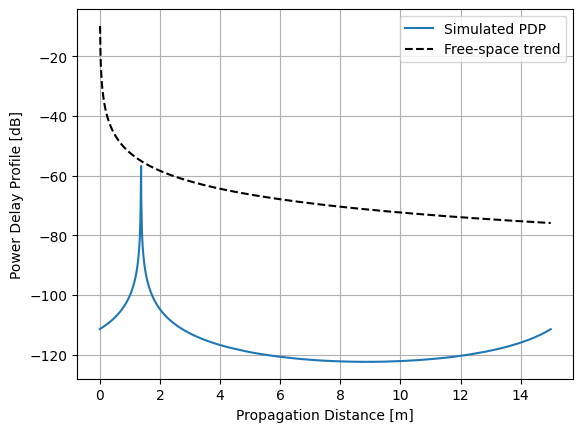

In [7]:
h_time = np.fft.ifft(h, len(h))

# Calculate the Power Delay Profile
pdp = 10 * np.log10(np.abs(h_time) ** 2)

print(pdp.shape)

fig, ax = plt.subplots()

# Extract our sample frequency and calculate the propagation distance from that.
fc = config['sub_thz']['fc']
gtx = 17 # in dB
grx = 6 # in dB
tsample = 1 / config['sub_thz']['bw']
prop_distance = np.arange(0, len(pdp)) * tsample * 3e8

# Now also calculate the free-space path loss.
fspl = 20 * np.log10(prop_distance) + 20 * np.log10(fc) + 20 * np.log10((4 * np.pi) / 3e8) - gtx - grx

# Plot the power delay profile with the free-space path loss on top.
ax.plot(prop_distance, pdp, label="Simulated PDP")
ax.plot(prop_distance, -fspl, '--', color="black", label="Free-space trend")
ax.set_ylabel("Power Delay Profile [dB]")
ax.set_xlabel("Propagation Distance [m]")
ax.grid(True, 'both')
ax.legend()
#ax.set_xscale('log')

data = np.array([prop_distance, pdp, fspl])
df = pd.DataFrame(data.T, columns=["Time [s]", "PDP [dB]", "FSPL [dB]"])
df.to_csv(f"pdp-{x:.2f}x-{y:.2f}y-{z:.2f}z.csv")